# 05 — Deep learning credit-risk model

This notebook trained a compact PyTorch multilayer perceptron on the same engineered features. The neural network was included to compare a deep tabular model against tree-based and linear baselines, while keeping the architecture small enough for a normal laptop.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_package.config import ensure_project_dirs, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET
from project_package.plotting import save_figure
from project_package.reporting import save_table

ensure_project_dirs()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

import joblib
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from project_package.features import get_feature_columns
from project_package.evaluation import classification_metrics

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train_split.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test_split.csv")
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(int)
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)

numeric_cols, categorical_cols = get_feature_columns(train_df)
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_cols),
])
X_train_arr = preprocessor.fit_transform(X_train).astype("float32")
X_test_arr = preprocessor.transform(X_test).astype("float32")
y_train_arr = y_train.values.astype("float32")
y_test_arr = y_test.values.astype("float32")
print(X_train_arr.shape, X_test_arr.shape)

(24000, 54) (6000, 54)


## Network architecture

The model used fully connected layers with batch normalization and dropout. The positive-class weight compensated for class imbalance during binary cross-entropy training.

In [3]:
torch.manual_seed(42)

class CreditRiskMLP(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = CreditRiskMLP(X_train_arr.shape[1])
pos_weight = torch.tensor([(len(y_train_arr) - y_train_arr.sum()) / max(y_train_arr.sum(), 1)], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_ds = TensorDataset(torch.from_numpy(X_train_arr), torch.from_numpy(y_train_arr))
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

## Training loop

The training history was saved for plotting and reporting. The loop was intentionally compact and reproducible.

In [4]:
history = []
for epoch in range(1, 26):
    model.train()
    losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        test_logits = model(torch.from_numpy(X_test_arr))
        test_proba = torch.sigmoid(test_logits).numpy()
    metrics = classification_metrics(y_test_arr, test_proba, threshold=0.5)
    history.append({"epoch": epoch, "train_loss": float(np.mean(losses)), **metrics})

history_df = pd.DataFrame(history)
save_table(history_df, "05_mlp_training_history.csv")
history_df.tail()

,epoch,train_loss,roc_auc,pr_auc,brier_score,log_loss,f1,precision,recall,balanced_accuracy,threshold
20,21,0.842895,0.777729,0.558632,0.171358,0.520986,0.538199,0.491589,0.594574,0.709977,0.5
21,22,0.845581,0.781194,0.563127,0.181046,0.545289,0.535509,0.465258,0.630746,0.712441,0.5
22,23,0.840668,0.779287,0.562176,0.182898,0.551998,0.533375,0.458085,0.638282,0.711929,0.5
23,24,0.838322,0.779434,0.563492,0.175851,0.533097,0.536697,0.474783,0.617182,0.711651,0.5
24,25,0.839131,0.777646,0.557789,0.185636,0.557260,0.529539,0.449108,0.645064,0.710184,0.5


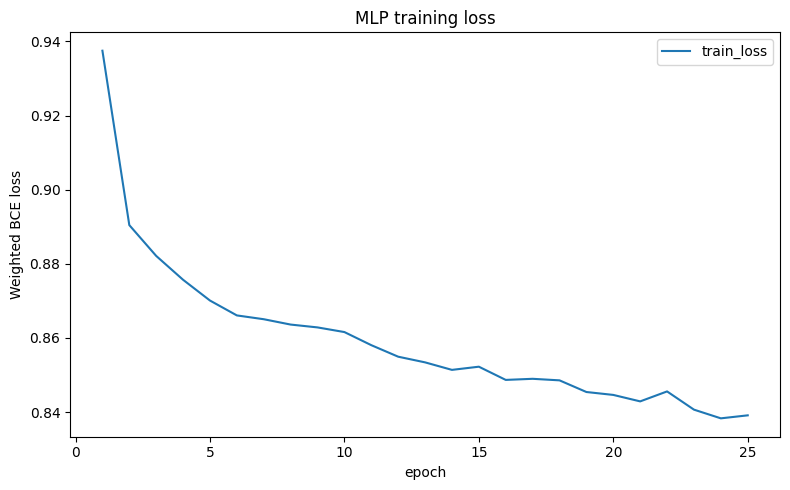

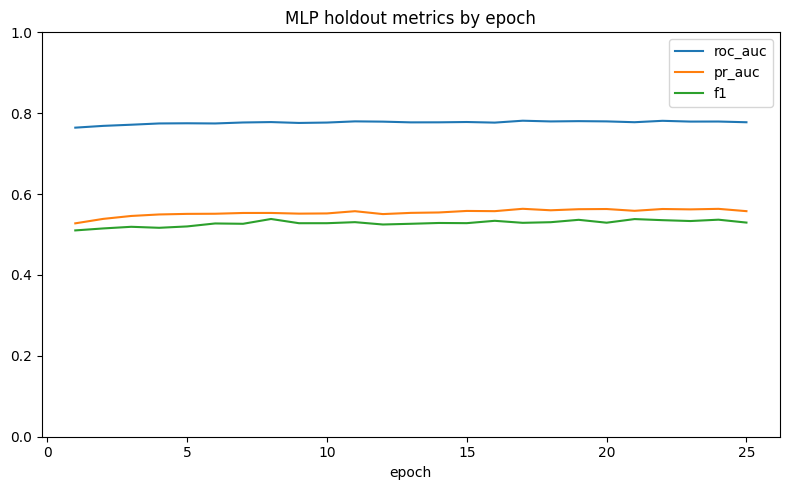

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
history_df.plot(x="epoch", y=["train_loss"], ax=ax)
ax.set_title("MLP training loss")
ax.set_ylabel("Weighted BCE loss")
save_figure(fig, "05_mlp_training_loss.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
history_df.plot(x="epoch", y=["roc_auc", "pr_auc", "f1"], ax=ax)
ax.set_title("MLP holdout metrics by epoch")
ax.set_ylim(0, 1)
save_figure(fig, "05_mlp_holdout_metrics_by_epoch.png")
plt.show()

## Saving neural-network predictions and artifacts

The PyTorch state dictionary and preprocessing object were saved separately. The holdout probabilities were saved in the same format as the standard-model predictions.

In [6]:
model.eval()
with torch.no_grad():
    mlp_proba = torch.sigmoid(model(torch.from_numpy(X_test_arr))).numpy()

mlp_metrics = classification_metrics(y_test_arr, mlp_proba, threshold=0.5)
save_table(pd.DataFrame([{"model": "mlp", **mlp_metrics}]), "05_mlp_metrics.csv")
pd.DataFrame({"y_true": y_test.values, "proba_mlp": mlp_proba}).to_csv(PROCESSED_DIR / "test_predictions_mlp.csv", index=False)

torch.save(model.state_dict(), MODELS_DIR / "mlp_credit_risk_state_dict.pt")
joblib.dump(preprocessor, MODELS_DIR / "mlp_preprocessor.joblib")
print("Saved MLP artifacts and predictions.")

Saved MLP artifacts and predictions.
